This notebook attemps to replicate the analysis done in NPS's climate future project for various levels of downscaled CMIP6 data

In [14]:
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
from shapely.geometry import mapping

In [12]:
# Load the dataset and inspect its structure
nc = xr.open_dataset('isimip/data/processed/gfdl-esm4_r1i1p1f1_w5e5_historical_pr_jotr_monthly.nc', engine="netcdf4")
nc

<xarray.Dataset> Size: 95kB
Dimensions:    (time: 1980, bnds: 2, lon: 3, lat: 2)
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16 ... 2014-12-16
  * lon        (lon) float64 24B -116.2 -115.8 -115.2
  * lat        (lat) float64 16B 34.25 33.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32kB ...
    pr         (time, lat, lon) float32 48kB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...
    history:      Fri Jan 30 17:40:16 2026: cdo mergetime gfdl-esm4_r1i1p1f1_...
    frequency:    mon
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

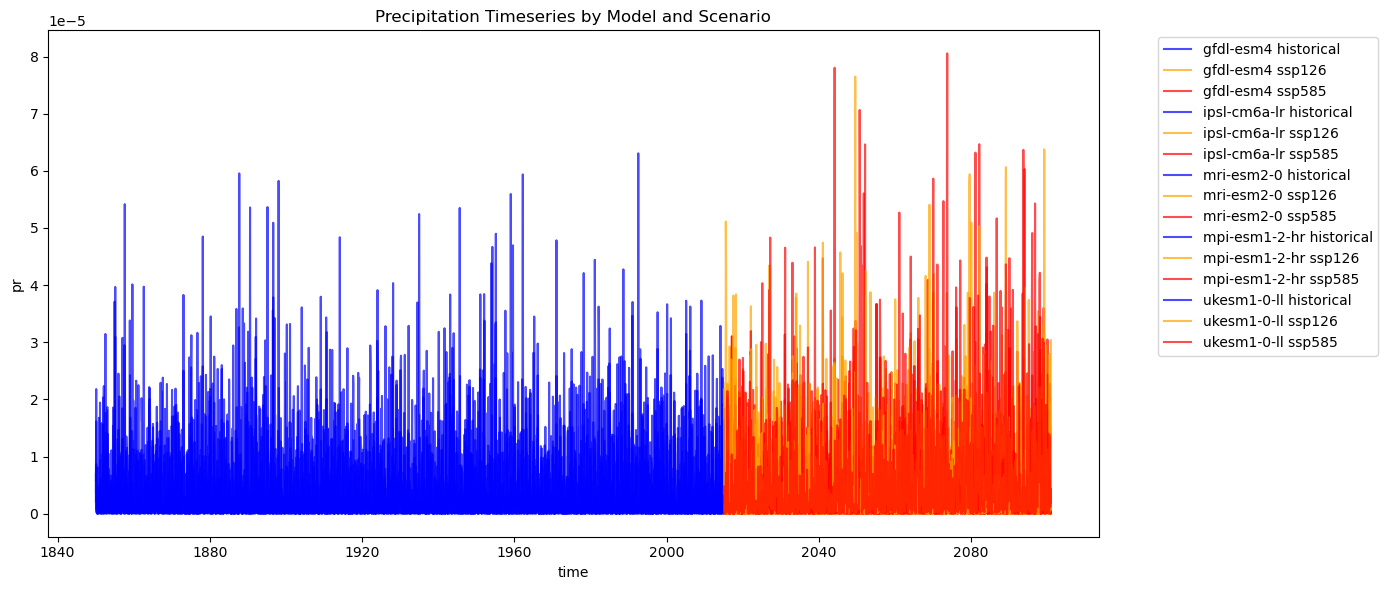

In [ ]:
# crop to only pixels inside park boundary

def crop_to_park_boundary(nc, boundary):
    ''' Takes an xarray object and crops within the provided boundary (geopandas), 
    returning a clipped xarray object. '''
    
    # Select just the precipitation variable (time_bnds doesn't have spatial dims)
    nc_pr = nc['pr'].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    nc_pr = nc_pr.rio.write_crs("EPSG:4326", inplace=True)
    if nc_pr.rio.crs != boundary.crs:
        boundary = boundary.to_crs(nc_pr.rio.crs)
    nc_clipped = nc_pr.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)

    return(nc_clipped)

# spatially aggregate to average yearly timeseries
def plot_clipped_timeseries(ax, scenario, model, boundary):

    if scenario == "historical":
        color = "blue"
    elif scenario == "ssp126":
        color = "orange"
    elif scenario == "ssp585":
        color = "red"

    nc = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_{scenario}_pr_jotr_monthly.nc', engine="netcdf4")
    nc_clipped = crop_to_park_boundary(nc, boundary)
    
    # Calculate spatial mean
    ts = nc_clipped.mean(("lon", "lat"))
    
    # Calculate baseline mean (1979-2012)
    baseline = ts.sel(time=slice("1979", "2012")).mean("time")
    
    # Calculate anomaly
    anomaly = ts - baseline
    
    anomaly.plot(ax=ax, label=f"{model.split('_')[0]} {scenario}", color=color, alpha=0.7)

boundary = gpd.read_file('isimip/data/Joshua_Tree_National_Park.shp')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 6))

for model in ['gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2']:
    for scenario in ["historical", "ssp126", "ssp585"]:
        plot_clipped_timeseries(ax, scenario, model, boundary)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Precipitation Anomaly (relative to 1979-2012) by Model and Scenario')
ax.set_ylabel('Precipitation Anomaly')
plt.tight_layout()
plt.show()

# add to plot

## for all three scenarios and 5 models

Data extent:
  lon: -116.25 to -115.25
  lat: 33.75 to 34.25

Boundary extent:
[-116.45804115   33.67018976 -115.2622015    34.12934662]

Clipped data shape: (1980, 2, 3)


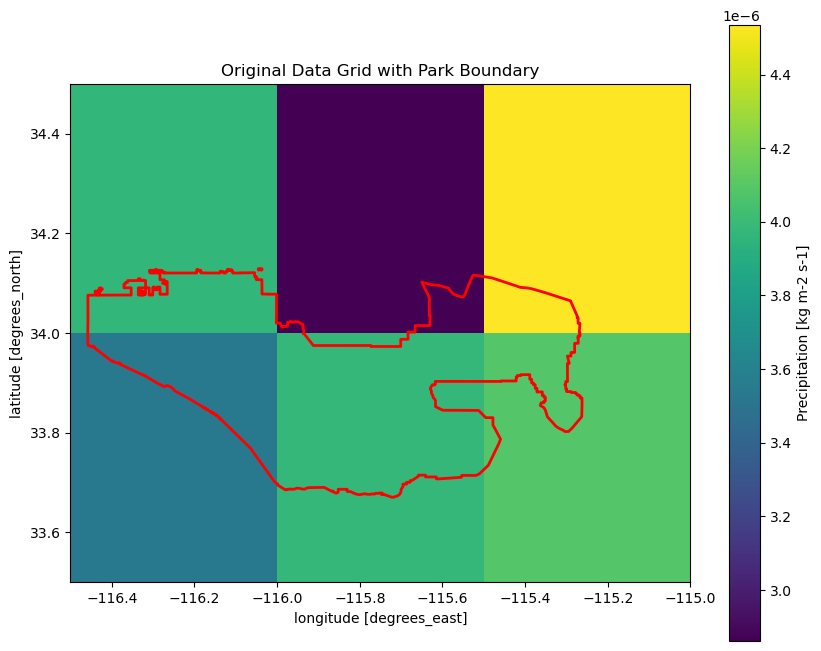